In [1]:
# Parameters
param1=1

In [2]:
from matplotlib import pyplot as plt
from scipy.spatial.distance import cdist
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA
from sklearn.metrics import accuracy_score

import torch
import numpy as np
from copy import deepcopy


from torch import nn
from umap import UMAP

from run_sim import Config, run_sim, run_sim_wrapper, create_data
from utils import *
from tqdm import tqdm
from tqdm import tqdm
from utils import *
import matplotlib as mpl
import scipy
from scipy.special import softmax
from functools import reduce



In [3]:
def calc_h_var(G, D, N, L, sig_X):
    return G**(2*L)*(2*D*sig_X)/(D+N)

In [4]:
C = Config()

C.G = 0.5
C.sig_h_2 = None
# C.gpu_id=1
# C.seed = 1
C.linear_net = True
# C.split_actions = True
# C.allow_backwards = True
C.learning_rate = 0.0001
C.L=5
C.print_progress = True
C.algo_name = 'Adam'
C.loss_fn = nn.CrossEntropyLoss()
C.length_corridors = [30]*1
# C.input_size = 10
C.max_move = 5
C.hidden_size = 50 # (C.length_corridors[0]+2*C.max_move+1 + 1)*len(C.length_corridors)
C.num_epochs = 1
C.scalar_actions = True
C.cyclic_corridors = False

In [5]:
data_dict_l = []
for max_move in [1, C.length_corridors[0]//4, C.length_corridors[0]]:
    C.max_move = max_move
    data_dict = run_sim_wrapper(C)
    data_dict_l.append(data_dict)
# X = data_dict['X'].cpu().numpy()
# y = data_dict['y'].cpu().numpy()
# corridor = data_dict['corridor']
# loc_X = data_dict['loc_X']
# loc_y = data_dict['loc_y']
# action_taken = data_dict['action_taken']
# hidden_states = data_dict['hidden_states']
# loss_l = data_dict['loss_l']
# accuracy_l = data_dict['accuracy_l']
# outputs = data_dict['outputs']
# hidden_l = data_dict['hidden_l']
# initial_weights = data_dict['initial_weights']
# final_weights = data_dict['final_weights']
# state_dict_l = data_dict['state_dict_l']
# C = data_dict['C']

Number of samples: 88
Input dimension: 31
Output dimension: 30
Number of actions: 1

Sig_2 of last hidden: 3.645914330263622e-05


100%|██████████| 1/1 [00:00<00:00,  6.00it/s]


Number of samples: 394
Input dimension: 31
Output dimension: 30
Number of actions: 1

Sig_2 of last hidden: 0.00037552608409896493


100%|██████████| 1/1 [00:00<00:00, 42.02it/s]


Number of samples: 900
Input dimension: 31
Output dimension: 30
Number of actions: 1

Sig_2 of last hidden: 0.003069845028221607


100%|██████████| 1/1 [00:00<00:00, 91.13it/s]


In [6]:
# from utils_plot import plot_pca
# for data_dict in data_dict_l:
#     plot_pca(data_dict)

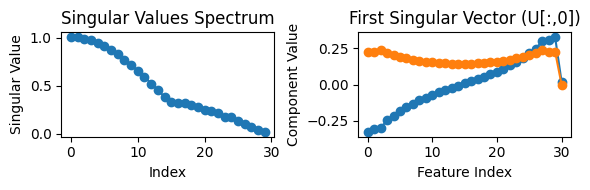

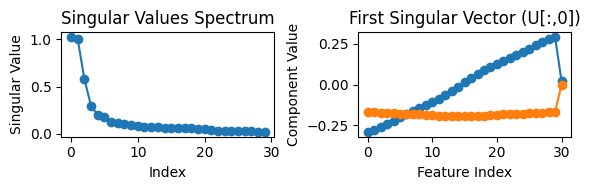

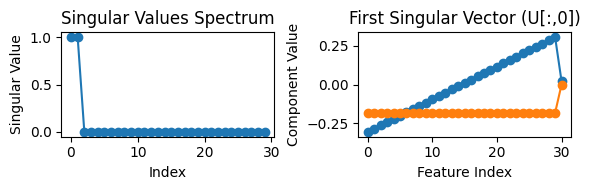

In [7]:

for data_dict in data_dict_l:
    X = data_dict['X'].cpu().numpy()
    y = data_dict['y'].cpu().numpy()

    # X -= X.mean(axis=1, keepdims=True)
    # y -= y.mean(axis=1, keepdims=True)

    XT_X = X.T @ X
    XT_y = X.T @ y
    S = np.linalg.pinv(XT_X) @ XT_y  

    # Singular value decomposition
    U, s, Vt = np.linalg.svd(S)

    # Plot singular values spectrum
    plt.figure(figsize=(6, 2))
    plt.subplot(1, 2, 1)
    plt.plot(s, 'o-')
    plt.title('Singular Values Spectrum')
    plt.xlabel('Index')
    plt.ylabel('Singular Value')

    # Plot first singular vector
    plt.subplot(1, 2, 2)
    plt.plot(U[:, 0], 'o-')
    plt.plot(U[:, 1], 'o-')
    plt.title('First Singular Vector (U[:,0])')
    plt.xlabel('Feature Index')
    plt.ylabel('Component Value')

    plt.tight_layout()
    plt.show()


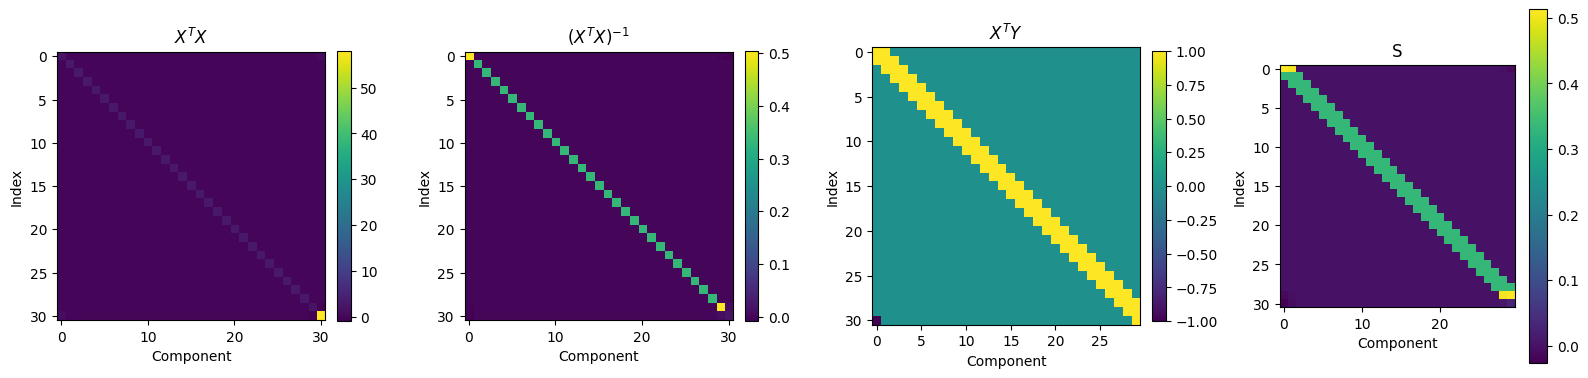

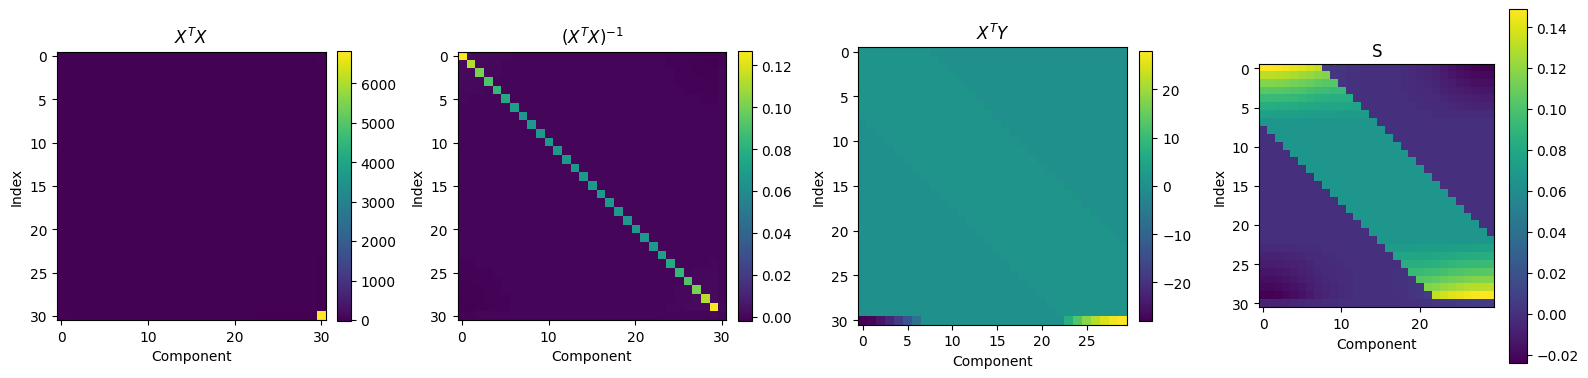

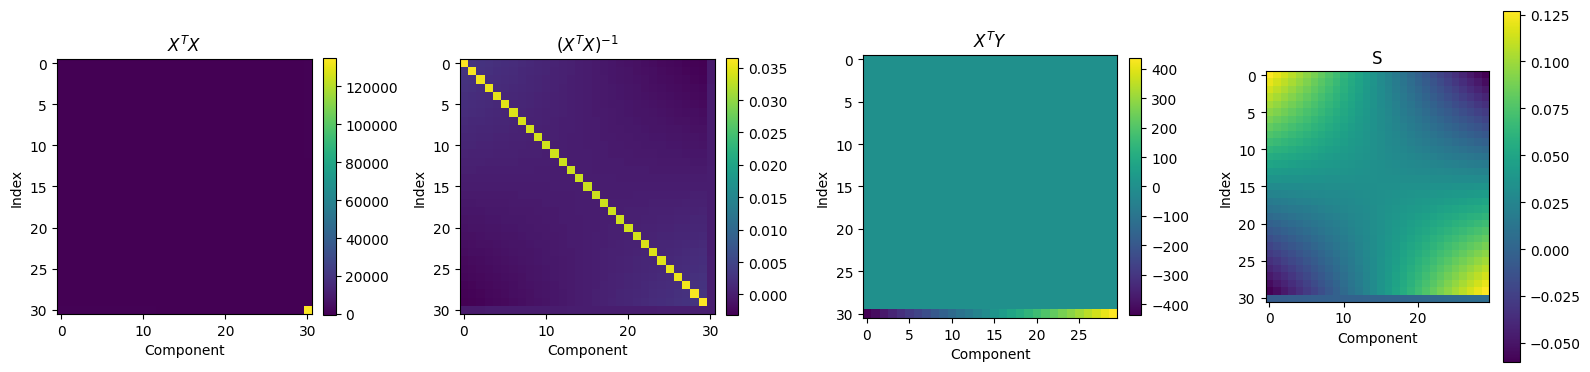

In [8]:
for data_dict in data_dict_l:
    X = data_dict['X'].cpu().numpy()
    y = data_dict['y'].cpu().numpy()

    XT_X = X.T @ X
    XT_y = X.T @ y
    S = np.linalg.pinv(XT_X) @ XT_y  
    # Visualize the key OLS matrices as images

    fig, axs = plt.subplots(1, 4, figsize=(16, 4))

    # 1. X^T X
    im0 = axs[0].imshow(XT_X)
    axs[0].set_title("$X^T X$")
    plt.colorbar(im0, ax=axs[0], fraction=0.046, pad=0.04)

    # 2. inv(X^T X) X^T y
    # This is S as computed previously, but let's show the intermediate inv(X^T X) @ XT_y too
    XTX_inv = np.linalg.pinv(XT_X)
    XTX_inv_XTy = XTX_inv @ XT_y

    im1 = axs[1].imshow(XTX_inv)
    axs[1].set_title("$\left(X^T X\\right)^{-1}$")
    plt.colorbar(im1, ax=axs[1], fraction=0.046, pad=0.04)


    im1 = axs[2].imshow(XT_y)
    axs[2].set_title("$X^TY$")
    plt.colorbar(im1, ax=axs[2], fraction=0.046, pad=0.04)

    # 3. S
    im2 = axs[3].imshow(np.atleast_2d(S))
    axs[3].set_title("S")
    plt.colorbar(im2, ax=axs[3])

    for ax in axs:
        ax.set_xlabel('Component')
        ax.set_ylabel('Index')

    plt.tight_layout()
    plt.show()


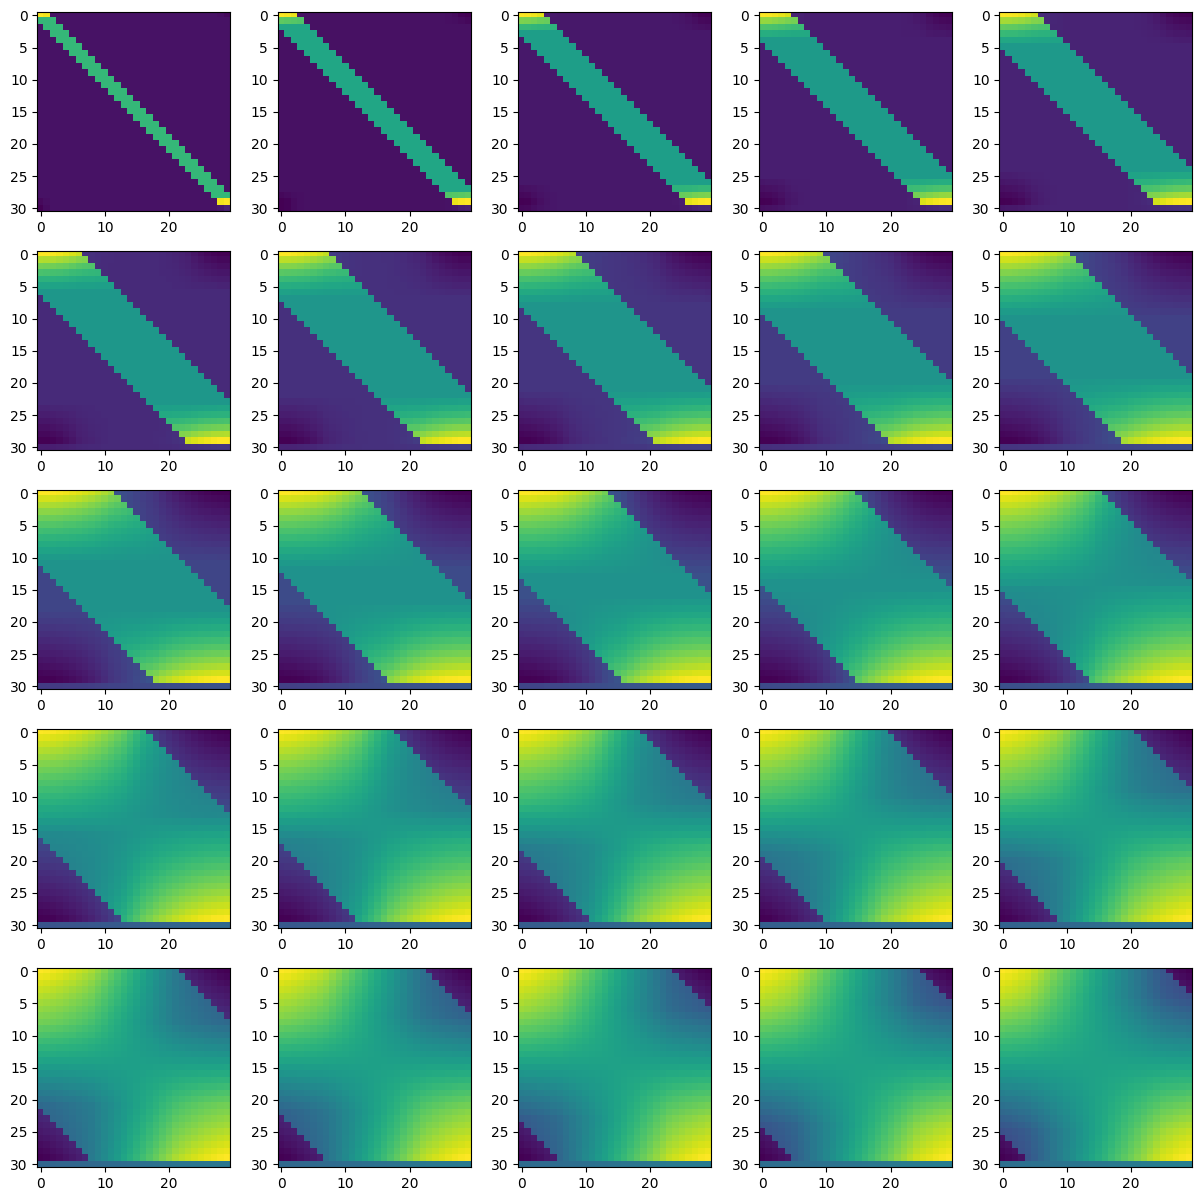

In [9]:
C.print_progress = False
N = C.length_corridors[0]
n = int(np.sqrt(N))
fig, axs = plt.subplots(n, n, figsize=(n*3, n*3))
for max_move, ax in zip(range(1,N), axs.flatten()):
    C.max_move = max_move
    data_dict = run_sim_wrapper(C)
    data_dict_l.append(data_dict)
    X = data_dict['X'].cpu().numpy()
    y = data_dict['y'].cpu().numpy()

    XT_X = X.T @ X
    XT_y = X.T @ y
    S = np.linalg.pinv(XT_X) @ XT_y  
    ax.imshow(S)

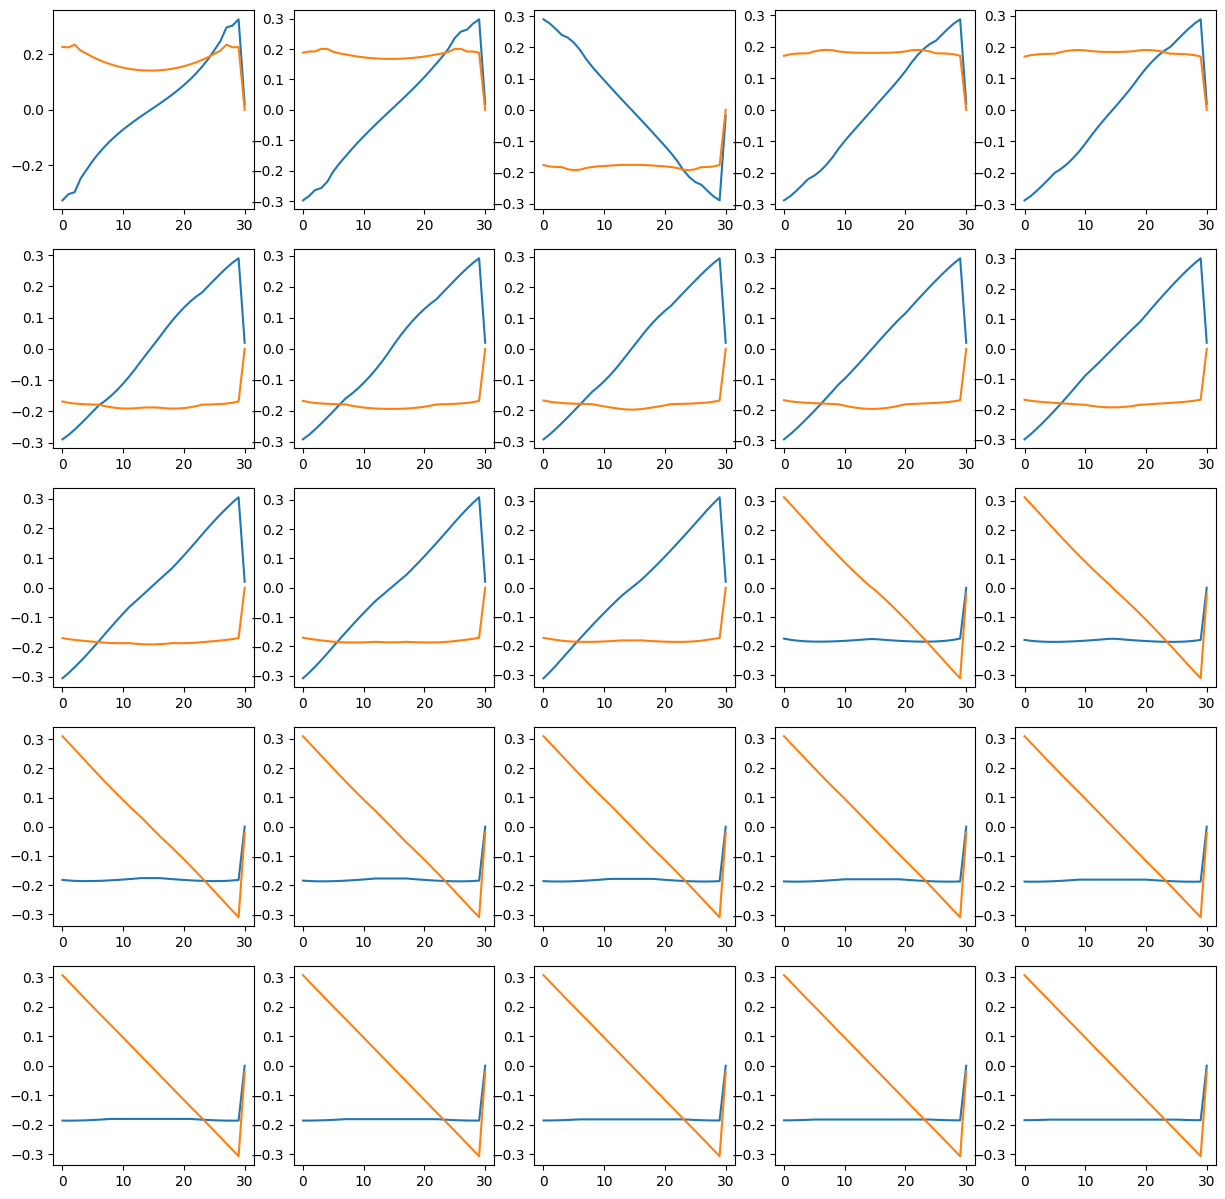

In [10]:
C.print_progress = False
N = C.length_corridors[0]
n = int(np.sqrt(N))
fig, axs = plt.subplots(n, n, figsize=(n*3, n*3))
for max_move, ax in zip(range(1,N), axs.flatten()):
    C.max_move = max_move
    data_dict = run_sim_wrapper(C)
    data_dict_l.append(data_dict)
    X = data_dict['X'].cpu().numpy()
    y = data_dict['y'].cpu().numpy()

    XT_X = X.T @ X
    XT_y = X.T @ y
    S = np.linalg.pinv(XT_X) @ XT_y  
    U, S, Vt = np.linalg.svd(S)
    ax.plot(U[:,:2])

100%|██████████| 29/29 [00:00<00:00, 32.49it/s]


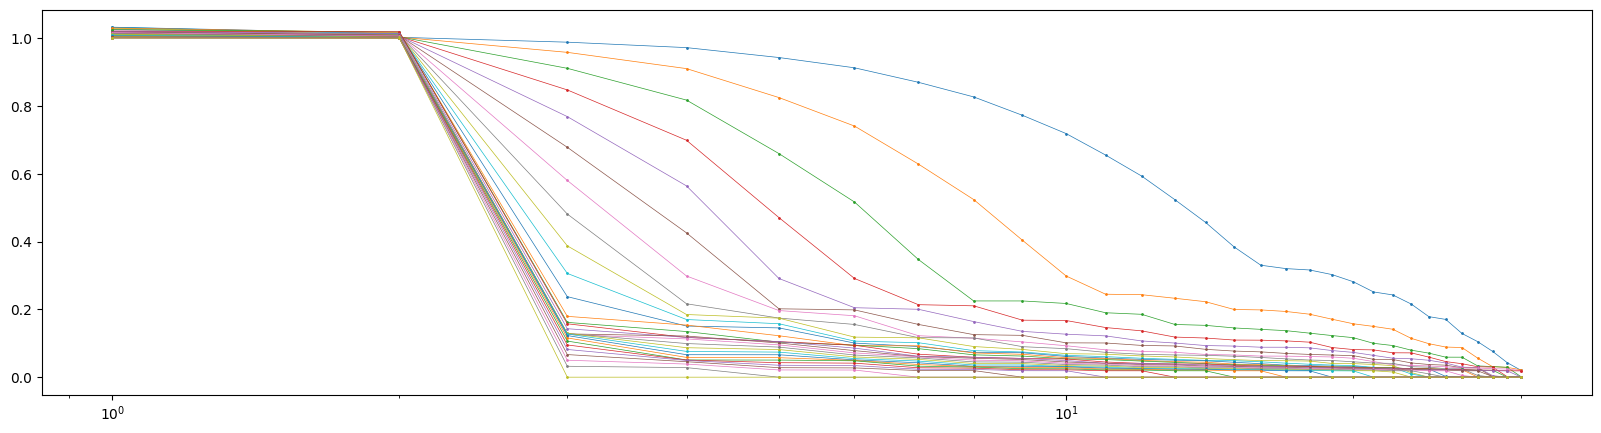

In [11]:
C.print_progress = False
N = C.length_corridors[0]
fig, ax = plt.subplots(1, 1, figsize=(20, 5))
for max_move in tqdm(range(1,N)):
    C.max_move = max_move
    data_dict = run_sim_wrapper(C)
    data_dict_l.append(data_dict)
    X = data_dict['X'].cpu().numpy()
    y = data_dict['y'].cpu().numpy()

    XT_X = X.T @ X
    XT_y = X.T @ y
    S = np.linalg.pinv(XT_X) @ XT_y  
    U, S, Vt = np.linalg.svd(S)
    plt.plot(np.arange(1, S.shape[0]+1), S, lw=0.5, marker='o', markersize=1)
plt.xscale('log')

In [12]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

def get_r2(y):
    x = np.arange(y.shape[0]).reshape(-1, 1)
    # Prepare the data for linear regression
    lr = LinearRegression()
    lr.fit(x, y)
    y_pred = lr.predict(x)
    r2 = r2_score(y, y_pred)
    return r2

In [13]:
C.print_progress = False
N = C.length_corridors[0]
PR_l = []
eigv_score_l = []
for max_move in tqdm(range(1,N)):
    C.max_move = max_move
    data_dict = run_sim_wrapper(C)
    data_dict_l.append(data_dict)
    X = data_dict['X'].cpu().numpy()
    y = data_dict['y'].cpu().numpy()

    XT_X = X.T @ X
    XT_y = X.T @ y
    S = np.linalg.pinv(XT_X) @ XT_y  
    U, S, Vt = np.linalg.svd(S)
    eigv_score_l.append(1-max(get_r2(U[:-1,0]), get_r2(U[:-1,1])))
    PR_l.append(np.sum(S)**2/np.sum(S**2))


100%|██████████| 29/29 [00:00<00:00, 39.28it/s]


Text(0, 0.5, 'Eigv Score')

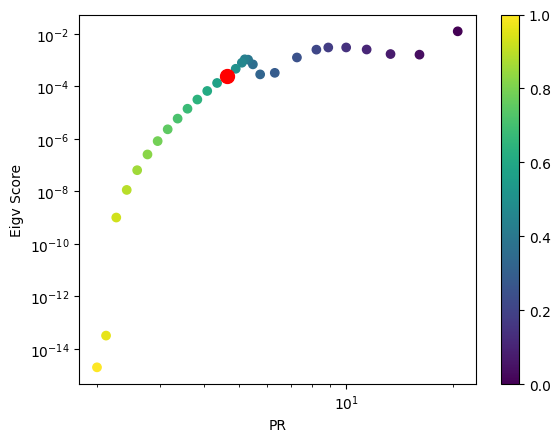

In [14]:
plt.scatter(PR_l, eigv_score_l, c=np.arange(1,N))
plt.scatter(PR_l[N//2], eigv_score_l[N//2], c='red', s=100)
plt.colorbar()
plt.yscale('log')
plt.xscale('log')
plt.xlabel('PR')
plt.ylabel('Eigv Score')

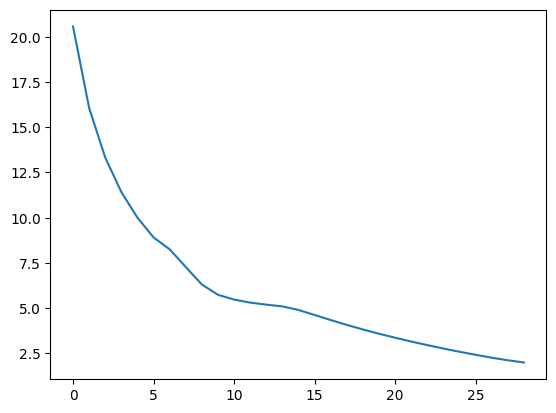

In [15]:
plt.plot(PR_l)